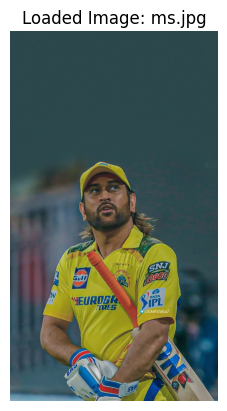

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/ms.jpg'
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # OpenCV loads images in BGR, matplotlib expects RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(image_rgb)
    plt.title('Loaded Image: ms.jpg')
    plt.axis('off') # Hide axes ticks
    plt.show()

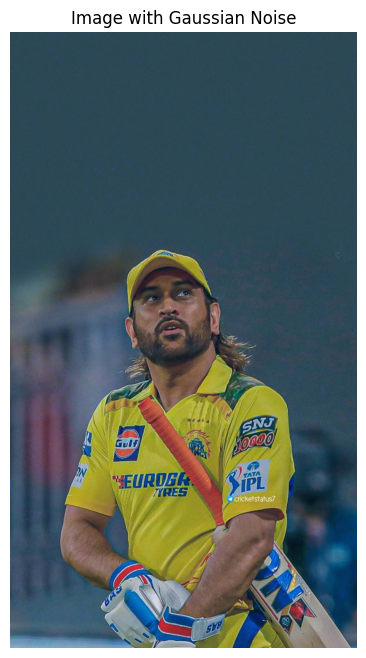

In [3]:
import numpy as np

# Define the mean and standard deviation for the Gaussian noise
mean = 0
std_dev = 25  # Adjust this value to control the intensity of the noise

# Generate Gaussian noise with the same shape as the image
# cv2.randn populates a given array with random numbers from a Gaussian distribution
noise = np.zeros(image.shape, np.uint8)
cv2.randn(noise, mean, std_dev)

# Add the noise to the image
noisy_image = cv2.add(image, noise) # Uses saturated arithmetic to handle clipping

# Convert the noisy image from BGR to RGB for displaying with matplotlib
noisy_image_rgb = cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB)

# Display the noisy image
plt.figure(figsize=(8, 8))
plt.imshow(noisy_image_rgb)
plt.title('Image with Gaussian Noise')
plt.axis('off')
plt.show()

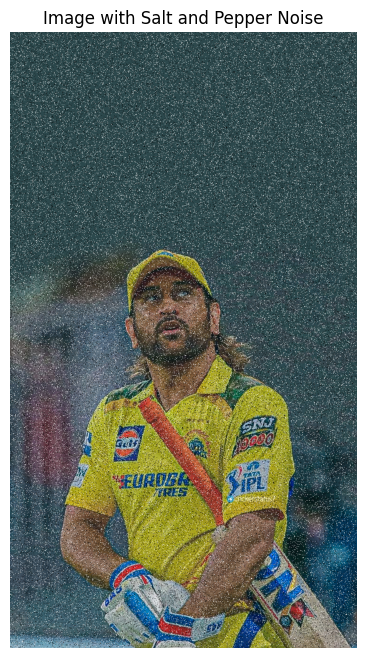

In [4]:
import numpy as np

# Create a copy of the original image to add noise to
salt_pepper_image = np.copy(image)

# Define the proportion of pixels to be affected by noise
salt_vs_pepper_ratio = 0.5 # 0.5 means equal salt and pepper
noise_amount = 0.04 # Percentage of pixels to affect (e.g., 4%)

# Get image dimensions
H, W, C = image.shape

# Add Salt noise
num_salt = np.ceil(noise_amount * image.size * salt_vs_pepper_ratio)
coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
salt_pepper_image[coords[0], coords[1], :] = 255

# Add Pepper noise
num_pepper = np.ceil(noise_amount * image.size * (1.0 - salt_vs_pepper_ratio))
coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
salt_pepper_image[coords[0], coords[1], :] = 0

# Convert the noisy image from BGR to RGB for displaying with matplotlib
salt_pepper_image_rgb = cv2.cvtColor(salt_pepper_image, cv2.COLOR_BGR2RGB)

# Display the image with salt and pepper noise
plt.figure(figsize=(8, 8))
plt.imshow(salt_pepper_image_rgb)
plt.title('Image with Salt and Pepper Noise')
plt.axis('off')
plt.show()

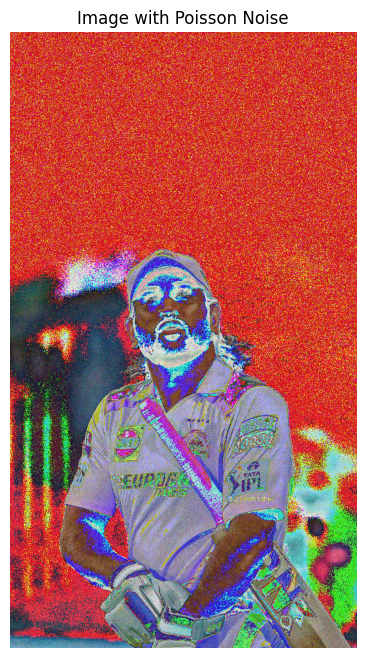

In [5]:
import numpy as np

# Create a copy of the original image
poisson_image = np.copy(image)

# To apply Poisson noise, the image data should be scaled to a range that represents photon counts
# The mean of the Poisson distribution is often related to the intensity of the pixel.
# We'll scale the pixel values to a higher range (e.g., multiply by 255/max_intensity) to simulate photon counts.
# Then apply Poisson noise and scale back.

# Convert image to float for calculation
poisson_image = poisson_image.astype(np.float32)

# Normalize pixel values to 0-1 range to prepare for Poisson distribution scaling
# Then multiply by a factor (e.g., 50 to 100) to get meaningful 'photon counts'
# A higher factor will result in less apparent noise (smoother Poisson)
# A lower factor will result in more apparent noise (grainier Poisson)
vals = 2 * np.sqrt(poisson_image / 255.0) * 255.0 # Example scaling, you can adjust the multiplier
poisson_image = np.random.poisson(vals).astype(np.uint8)

# Ensure pixel values are within the valid range [0, 255]
poisson_image = np.clip(poisson_image, 0, 255)

# Convert the noisy image from BGR to RGB for displaying with matplotlib
poisson_image_rgb = cv2.cvtColor(poisson_image, cv2.COLOR_BGR2RGB)

# Display the image with Poisson noise
plt.figure(figsize=(8, 8))
plt.imshow(poisson_image_rgb)
plt.title('Image with Poisson Noise')
plt.axis('off')
plt.show()

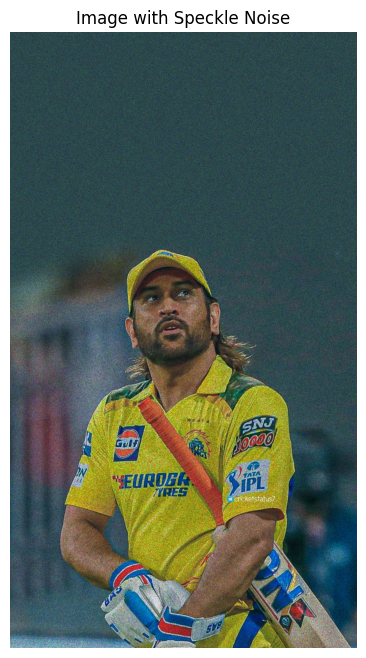

In [6]:
import numpy as np

# Create a copy of the original image to add noise to
speckle_image = np.copy(image)

# Convert image to float32 for calculations
speckle_image = speckle_image.astype(np.float32) / 255.0  # Normalize to [0, 1]

# Define the standard deviation for the speckle noise
# Adjust this value to control the intensity of the noise
# A smaller value (e.g., 0.1) will result in less noise
# A larger value (e.g., 0.5) will result in more noise
std_dev_speckle = 0.2

# Generate Gaussian noise (multiplicative for speckle)
# The noise is normally distributed with mean 0 and standard deviation std_dev_speckle
noise = np.random.normal(0, std_dev_speckle, speckle_image.shape)

# Apply speckle noise: noisy_image = original_image + original_image * noise
speckle_image = speckle_image + speckle_image * noise

# Clip the pixel values to be within [0, 1] and then scale back to [0, 255]
speckle_image = np.clip(speckle_image, 0, 1)
speckle_image = (speckle_image * 255).astype(np.uint8)

# Convert the noisy image from BGR to RGB for displaying with matplotlib
speckle_image_rgb = cv2.cvtColor(speckle_image, cv2.COLOR_BGR2RGB)

# Display the image with speckle noise
plt.figure(figsize=(8, 8))
plt.imshow(speckle_image_rgb)
plt.title('Image with Speckle Noise')
plt.axis('off')
plt.show()